In [1]:
import os, datetime
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from tensorflow import keras
from utils.dataset import load_dataset_v2
from utils.miscellaneous import create_seq_dataset_multiple_input_single_output
from utils.layer import FeatureWiseScalingLayer, DecompositionLayer
from utils.assemble_model import build_reg_model
from matplotlib.ticker import MultipleLocator, FuncFormatter


print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
TensorFlow version: 2.10.0
Num GPUs Available: 1
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
feature_name_list = ['inlet_pressure(bar)', 'outlet_pressure(bar)', 'pump_speed(rpm)']
target_name = 'outlet_flowrate(lpm)'

file_name_list = os.listdir(os.path.join('data', 'ver_3'))
data_list = []

for file_name in file_name_list:
    file_path = os.path.join('data', 'ver_3', file_name)
    data = pd.read_csv(file_path)
    data.columns = ['time(sec)'] + feature_name_list + [target_name]

    max_time = np.round(data['time(sec)'].max(), 0)
    time_ref_arr = np.arange(0, max_time, 0.5)
    sorted_data = []

    for ref_time in time_ref_arr:
        idx = np.argmin(np.abs(data['time(sec)'].to_numpy() - ref_time))
        sorted_data.append(data.iloc[idx, :])

    sorted_data = pd.DataFrame(sorted_data)
    sorted_data.reset_index(drop=True, inplace=True)
    data_list.append(data)

data = pd.concat(data_list, axis=0)
data.shape

(16375, 5)

In [3]:
data

,time(sec),inlet_pressure(bar),outlet_pressure(bar),pump_speed(rpm),outlet_flowrate(lpm)
0,0.143,-0.129,-0.114,1,0.000
1,0.256,-0.129,-0.116,1,0.000
2,0.382,-0.129,-0.122,1,0.000
3,0.507,-0.128,-0.107,1,0.000
4,0.622,-0.129,-0.101,1,0.000
...,...,...,...,...,...
2814,367.272,-0.155,0.078,3,262.719
2815,367.404,-0.155,0.060,3,279.999
2816,367.576,-0.156,0.069,3,279.999
2817,367.704,-0.155,0.060,3,279.999


In [4]:
dataset = data.copy()
dataset = dataset[dataset[target_name] > 1]
dataset.reset_index(drop=True, inplace=True)

dataset = dataset[feature_name_list+[target_name]].to_numpy()
dataset.shape

(14328, 4)

In [5]:
n_samples = 1000
max_len = 100

# random_start_idx = np.random.randint(low=0, high=new_dataset.shape[0]-max_len, size=n_samples)
# random_len_idx = np.random.randint(low=300, high=max_len+1, size=n_samples)
#
# buf_1 = np.empty(shape=(0, new_dataset.shape[1]))
#
# for i, j in zip(random_start_idx, random_len_idx):
#     buf_1 = np.concatenate([buf_1, new_dataset[i:i+j, :]], axis=0)


random_start_idx = np.random.randint(low=0, high=dataset.shape[0]-max_len, size=n_samples)
random_len_idx = np.random.randint(low=20, high=max_len+1, size=n_samples)

buf_2 = np.empty(shape=(0, dataset.shape[1]))

for i, j in zip(random_start_idx, random_len_idx):
    buf_2 = np.concatenate([buf_2, dataset[i:i+j, :]*0.90], axis=0)


random_start_idx = np.random.randint(low=0, high=dataset.shape[0]-max_len, size=n_samples)
random_len_idx = np.random.randint(low=10, high=max_len+1, size=n_samples)

buf_3 = np.empty(shape=(0, dataset.shape[1]))

for i, j in zip(random_start_idx, random_len_idx):
    buf_3 = np.concatenate([buf_3, dataset[i:i+j, :]*1.1], axis=0)


augment_dataset = np.concatenate([buf_2, buf_3], axis=0)

print(augment_dataset.shape)
print((augment_dataset.itemsize * augment_dataset.size)/(1024**2))

(112483, 4)
3.432708740234375


In [6]:
seq_len = 20

train_feature, train_target = create_seq_dataset_multiple_input_single_output(data=augment_dataset, seq_len=seq_len,pred_distance=0,
                                                                              target_idx_pos=augment_dataset.shape[1]-1)
val_feature, val_target = create_seq_dataset_multiple_input_single_output(data=dataset, seq_len=seq_len, pred_distance=0,
                                                                          target_idx_pos=dataset.shape[1]-1)

train_target = np.squeeze(train_target)
val_target = np.squeeze(val_target)

print(train_feature.shape, train_target.shape)
print(val_feature.shape, val_target.shape)

print((train_feature.itemsize * train_feature.size)/(1024**2))
print((train_target.itemsize * train_target.size)/(1024**2))

creating sequence dataset...:   0%|          | 0/112483 [00:00<?, ?it/s]

creating sequence dataset...:   0%|          | 0/14328 [00:00<?, ?it/s]

(112464, 20, 3) (112464,)
(14309, 20, 3) (14309,)
51.48193359375
0.8580322265625


In [7]:
model = build_reg_model(input_shape=(train_feature.shape[1:]), d_dims=128, dropout_rate=0.5, learning_rate=0.001)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 20, 3)]      0           []                               
                                                                                                  
 tf.__operators__.getitem (Slic  (None, 20, 2)       0           ['input_1[0][0]']                
 ingOpLambda)                                                                                     
                                                                                                  
 tf.__operators__.getitem_1 (Sl  (None, 20, 1)       0           ['input_1[0][0]']                
 icingOpLambda)                                                                                   
                                                                                              

In [8]:
# keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, show_layer_activations=True, show_dtype=True)


In [9]:
total_params = model.count_params()
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable_params = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print("--- 모델 파라미터 요약 ---")
print(f"Total params: {total_params:,}")
print(f"Trainable params: {int(trainable_params):,}")
print(f"Non-trainable params: {int(non_trainable_params):,}")

--- 모델 파라미터 요약 ---
Total params: 506,123
Trainable params: 504,839
Non-trainable params: 1,284


In [10]:
bytes_per_param_float32 = 4
total_bytes = total_params * bytes_per_param_float32

total_kb = total_bytes / 1024
total_mb = total_kb / 1024

print(f"--- 32비트 (float32) 기준 계산 ---")
print(f"총 파라미터 수: {total_params:,}")
print(f"총 용량 (MB): {total_mb:.2f} MB")

--- 32비트 (float32) 기준 계산 ---
총 파라미터 수: 506,123
총 용량 (MB): 1.93 MB


In [ ]:
log_dir = "logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stop = keras.callbacks.EarlyStopping(monitor=f'val_loss', patience=500, verbose=0)
csv_logger = keras.callbacks.CSVLogger(f'result/log_{seq_len}.csv', append=False, separator=',')
model_chk_point = keras.callbacks.ModelCheckpoint(filepath=f'models/model_{seq_len}.keras', monitor="val_loss", verbose=2, save_best_only=True,
                                                  save_weights_only=False, mode="min", save_freq="epoch", initial_value_threshold=None)

model.fit(x=train_feature, y=train_target, validation_data=(val_feature, val_target), epochs=999999,
          batch_size=3000, verbose=0, callbacks=[early_stop, csv_logger, model_chk_point, tensorboard_callback])

In [12]:
model = keras.models.load_model(f'models/model_{seq_len}.keras', custom_objects={'FeatureWiseScalingLayer': FeatureWiseScalingLayer,
                                                                                 'DecompositionLayer': DecompositionLayer})

In [13]:
train_result = pd.read_csv(f'result/log_{seq_len}.csv')

loss_df = train_result['loss']
val_loss_df = train_result['val_loss']
mean_abs_loss_df = train_result['mean_absolute_error']
val_mean_abs_loss_df = train_result['val_mean_absolute_error']
mean_abs_per_loss_df = train_result['mean_absolute_percentage_error']
val_mean_abs_per_loss_df = train_result['val_mean_absolute_percentage_error']

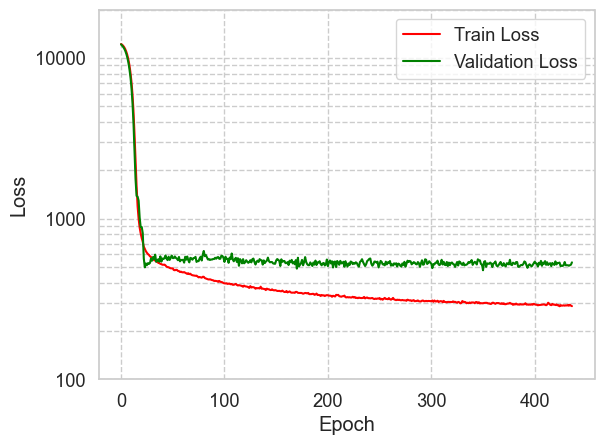

In [16]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

ax_1 = sns.lineplot(x=np.arange(0, len(loss_df)), y=loss_df, label='Train Loss', color='red')
sns.lineplot(x=np.arange(0, len(val_loss_df)), y=val_loss_df, label='Validation Loss', color='green')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')

plt.ylim(100, 20000)
plt.grid(True, which='minor', linestyle='--', linewidth=1.0)

formatter = FuncFormatter(lambda y, pos: f'{y:.0f}')
ax_1.yaxis.set_major_formatter(formatter)

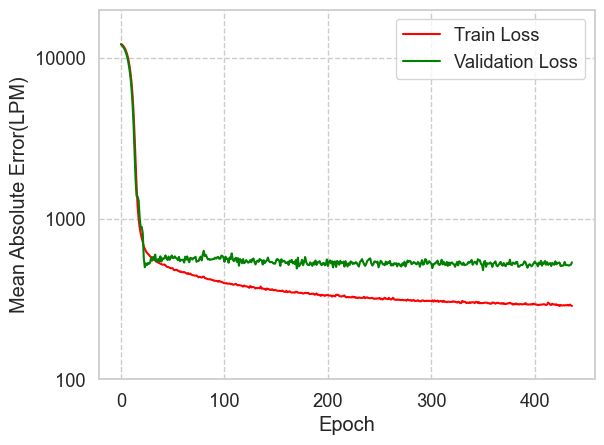

In [18]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

ax1 = sns.lineplot(x=np.arange(0, len(mean_abs_loss_df)), y=mean_abs_loss_df, label='Train Loss', color='red')
ax2 = sns.lineplot(x=np.arange(0, len(val_mean_abs_loss_df)), y=val_mean_abs_loss_df, label='Validation Loss', color='green')

plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error(LPM)')

#plt.ylim(0, 1000)

for axis in [ax1, ax2]:
    axis.yaxis.set_major_locator(MultipleLocator(100))

plt.ylim(100, 20000)

plt.yscale('log')

formatter = FuncFormatter(lambda y, pos: f'{y:.0f}')
ax1.yaxis.set_major_formatter(formatter)

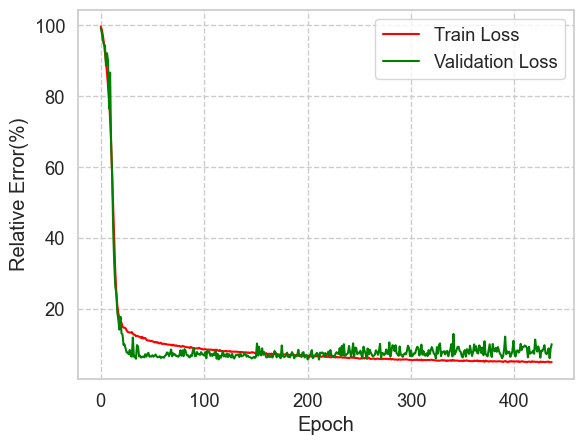

In [19]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

ax1 = sns.lineplot(x=np.arange(0, len(mean_abs_per_loss_df)), y=mean_abs_per_loss_df, label='Train Loss', color='red')
ax2 = sns.lineplot(x=np.arange(0, len(val_mean_abs_per_loss_df)), y=val_mean_abs_per_loss_df, label='Validation Loss', color='green')

plt.xlabel('Epoch')

#plt.yscale('log')
#plt.ylim(10, 100)
plt.ylabel('Relative Error(%)')

formatter = FuncFormatter(lambda y, pos: f'{y:.0f}')
ax1.yaxis.set_major_formatter(formatter)

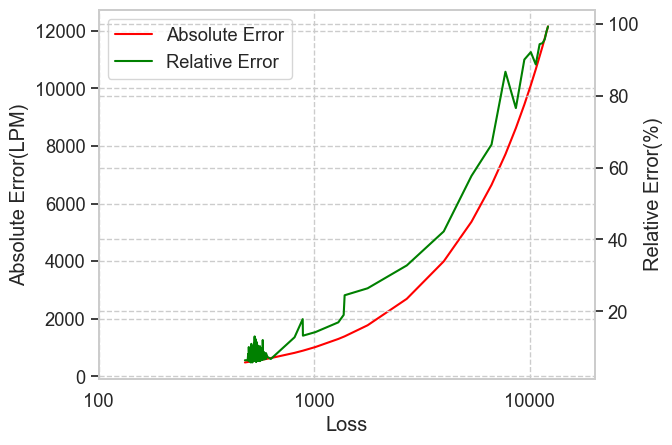

In [21]:
fig, ax1 = plt.subplots()

ax1 = sns.lineplot(x=val_loss_df, y=val_mean_abs_loss_df, ax=ax1, color='red')

ax1.set_xscale('log')
ax1.set_xlim(100, 20000)
ax1.set_xlabel('Loss')

#ax1.set_yscale('log')
#ax1.set_ylim(0, 1000)
#ax1.yaxis.set_major_locator(MultipleLocator(2000))
ax1.set_ylabel('Absolute Error(LPM)')

ax2 = ax1.twinx()

sns.lineplot(x=val_loss_df, y=val_mean_abs_per_loss_df, ax=ax2, color='green')

#ax2.set_yscale('log')
#ax2.set_ylim(500, 20000)
ax2.set_ylabel('Relative Error(%)')


line1, = ax1.lines
line2, = ax2.lines

ax1.legend([line1, line2], ['Absolute Error', 'Relative Error'], loc='upper left')

formatter = FuncFormatter(lambda y, pos: f'{y:.0f}')
ax1.xaxis.set_major_formatter(formatter)